In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [46]:
path = r'C:\Users\Magsihim_AI\Desktop\Project_Statbotics\actions_data\datasets\actions_df.csv'

df = pd.read_csv(path)

In [47]:
df

,score,autoLine,autoReef_botRow_nodeA,autoReef_botRow_nodeB,autoReef_botRow_nodeC,autoReef_botRow_nodeD,autoReef_botRow_nodeE,autoReef_botRow_nodeF,autoReef_botRow_nodeG,autoReef_botRow_nodeH,...,teleopReef_topRow_nodeH,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,possition,win
0,124,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,0.0,0.0,2783,1,False
1,144,True,False,False,False,False,False,False,False,False,...,True,True,True,True,False,0.0,0.0,2783,1,False
2,129,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,5.0,2.0,5045,1,True
3,118,True,False,False,False,False,False,False,False,False,...,True,True,True,True,True,1.0,0.0,538,1,True
4,67,True,False,False,False,False,False,False,False,False,...,False,False,True,True,True,1.0,1.0,6107,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114367,64,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,6.0,0.0,9995,3,False
114368,72,True,False,False,False,False,False,True,False,False,...,False,False,False,False,False,1.0,0.0,9991,3,True
114369,77,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,0.0,0.0,9994,3,False
114370,79,True,False,False,False,False,False,False,False,False,...,False,False,True,True,True,14.0,0.0,9993,3,False


In [48]:
# df.drop(['win', 'score'], axis = 1, inplace = True)
df.drop(['score'], axis = 1, inplace = True)

In [49]:
X = df.drop('win', axis = 1)
y = df['win']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 4)

In [51]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [52]:
# Define parameters for regression
params = {
    "objective": "reg:squarederror",  # for regression
    "eval_metric": "rmse",            # or "mae"
    "learning_rate": 0.1,
    "max_depth": 6,
    "seed": 42
}

# Watchlist to monitor training and validation
watchlist = [(dtrain_reg, "train"), (dtest_reg, "eval")]

# Train the model
model = xgb.train(params, dtrain_reg, num_boost_round=200, evals=watchlist, early_stopping_rounds=20)

[0]	train-rmse:0.49245	eval-rmse:0.49257
[1]	train-rmse:0.48612	eval-rmse:0.48638
[2]	train-rmse:0.48075	eval-rmse:0.48118
[3]	train-rmse:0.47625	eval-rmse:0.47683
[4]	train-rmse:0.47236	eval-rmse:0.47312
[5]	train-rmse:0.46914	eval-rmse:0.47003
[6]	train-rmse:0.46632	eval-rmse:0.46737
[7]	train-rmse:0.46384	eval-rmse:0.46505
[8]	train-rmse:0.46176	eval-rmse:0.46314
[9]	train-rmse:0.45989	eval-rmse:0.46138
[10]	train-rmse:0.45821	eval-rmse:0.45984
[11]	train-rmse:0.45676	eval-rmse:0.45849
[12]	train-rmse:0.45539	eval-rmse:0.45728
[13]	train-rmse:0.45420	eval-rmse:0.45623
[14]	train-rmse:0.45313	eval-rmse:0.45530
[15]	train-rmse:0.45226	eval-rmse:0.45458
[16]	train-rmse:0.45137	eval-rmse:0.45376
[17]	train-rmse:0.45053	eval-rmse:0.45308
[18]	train-rmse:0.44982	eval-rmse:0.45249
[19]	train-rmse:0.44908	eval-rmse:0.45190
[20]	train-rmse:0.44846	eval-rmse:0.45143
[21]	train-rmse:0.44798	eval-rmse:0.45109
[22]	train-rmse:0.44745	eval-rmse:0.45065
[23]	train-rmse:0.44700	eval-rmse:0.45031
[2

In [53]:
y_pred = model.predict(dtest_reg)

In [54]:
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"R²:   {r2:.3f}")


RMSE: 0.434
MAE:  0.389
R²:   0.246


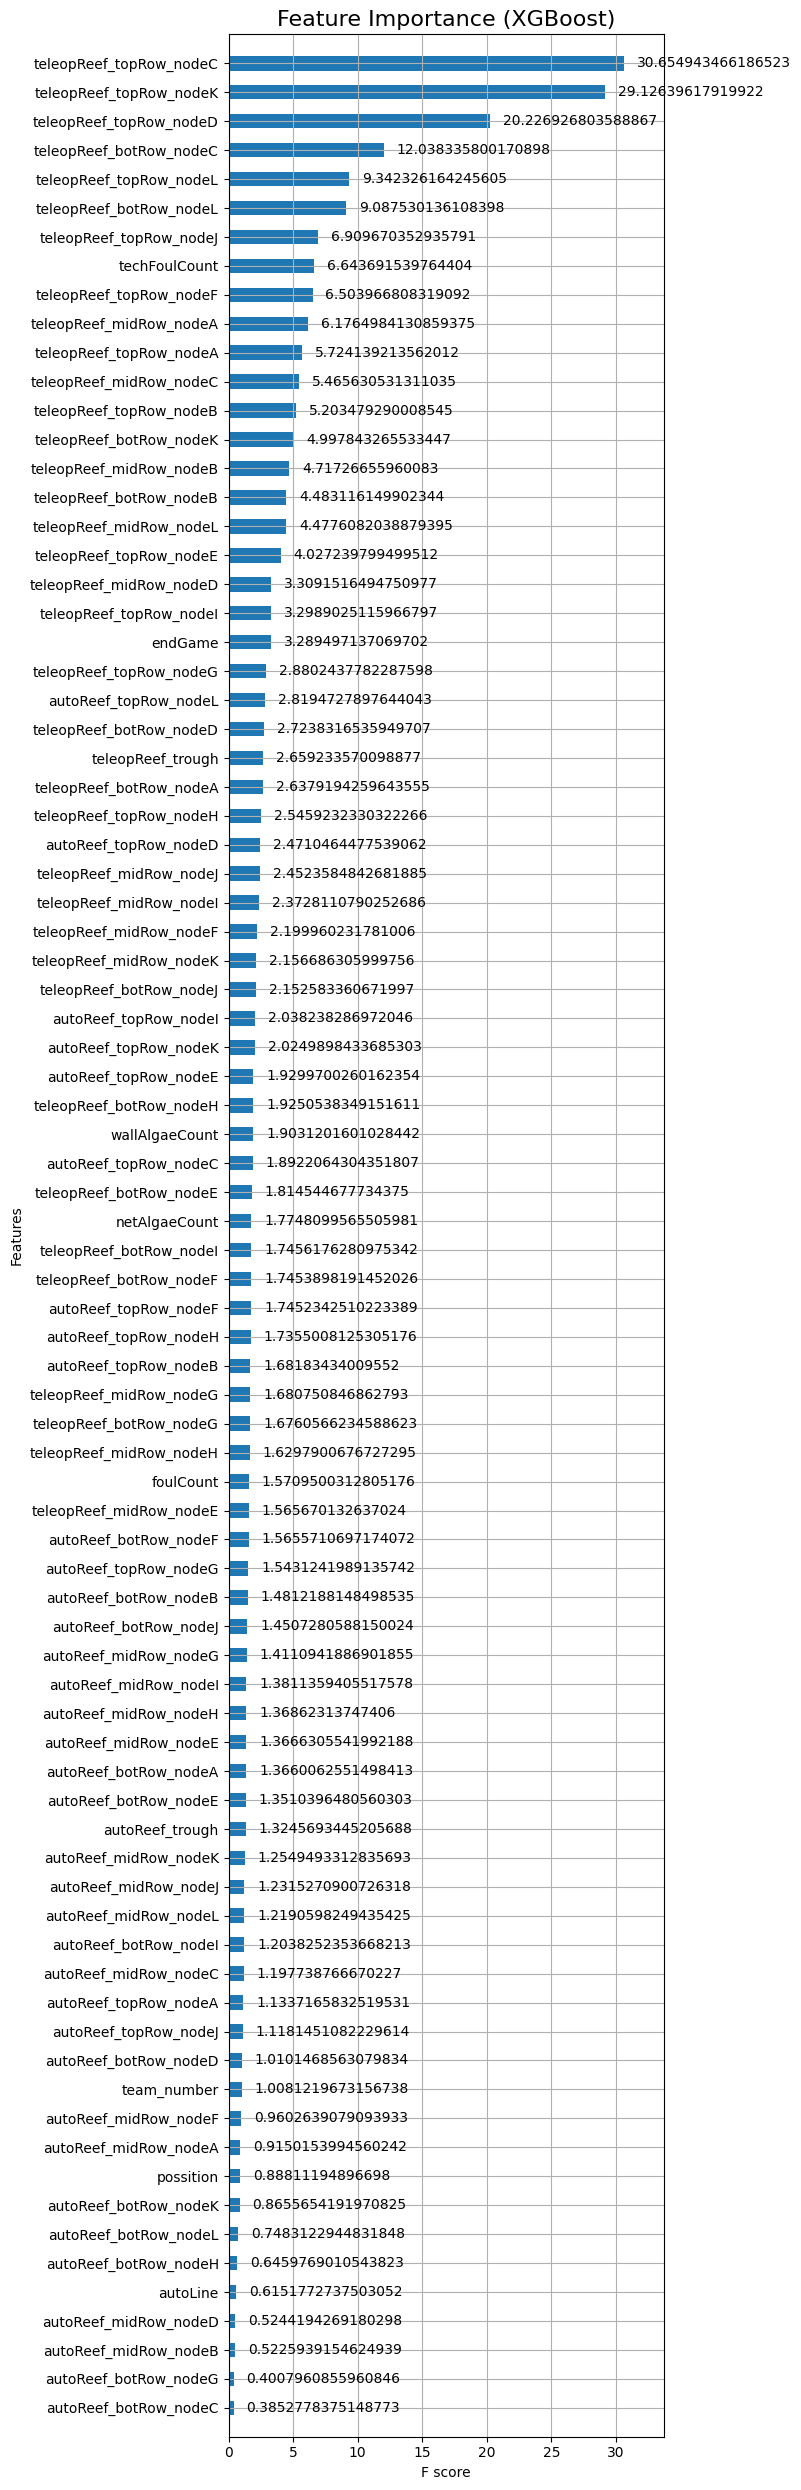

In [55]:
fig, ax = plt.subplots(figsize=(8, 25))  # now it will actually use this size

xgb.plot_importance(
    model,
    importance_type='gain',
    height=0.5,
    ax=ax  # 👈 tell XGBoost to draw on this axes
)

plt.title("Feature Importance (XGBoost)", fontsize=16)
plt.tight_layout()
plt.show()